In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import * 
from pathlib import Path

In [2]:

base = Path("clean_tables")
PRIMARY_KEY = "RowKey"

# 1. Load feature tables
dynamic_df = pd.read_csv(base / "dynamic_metrics.csv")
static_df  = pd.read_csv(base / "static_metrics.csv")
graph_df   = pd.read_csv(base / "graph_metrics.csv")

# 2. Merge feature tables first (numeric features)
df = dynamic_df.merge(static_df, on=PRIMARY_KEY)\
                       .merge(graph_df, on=PRIMARY_KEY)

# 3. FEATURES = numeric columns only (excluding PRIMARY_KEY)
FEATURES = df.select_dtypes(include=[np.number]).columns.tolist()
print("Number of numeric feature columns:", len(FEATURES), "Rows:", len(df))

Number of numeric feature columns: 22 Rows: 119693


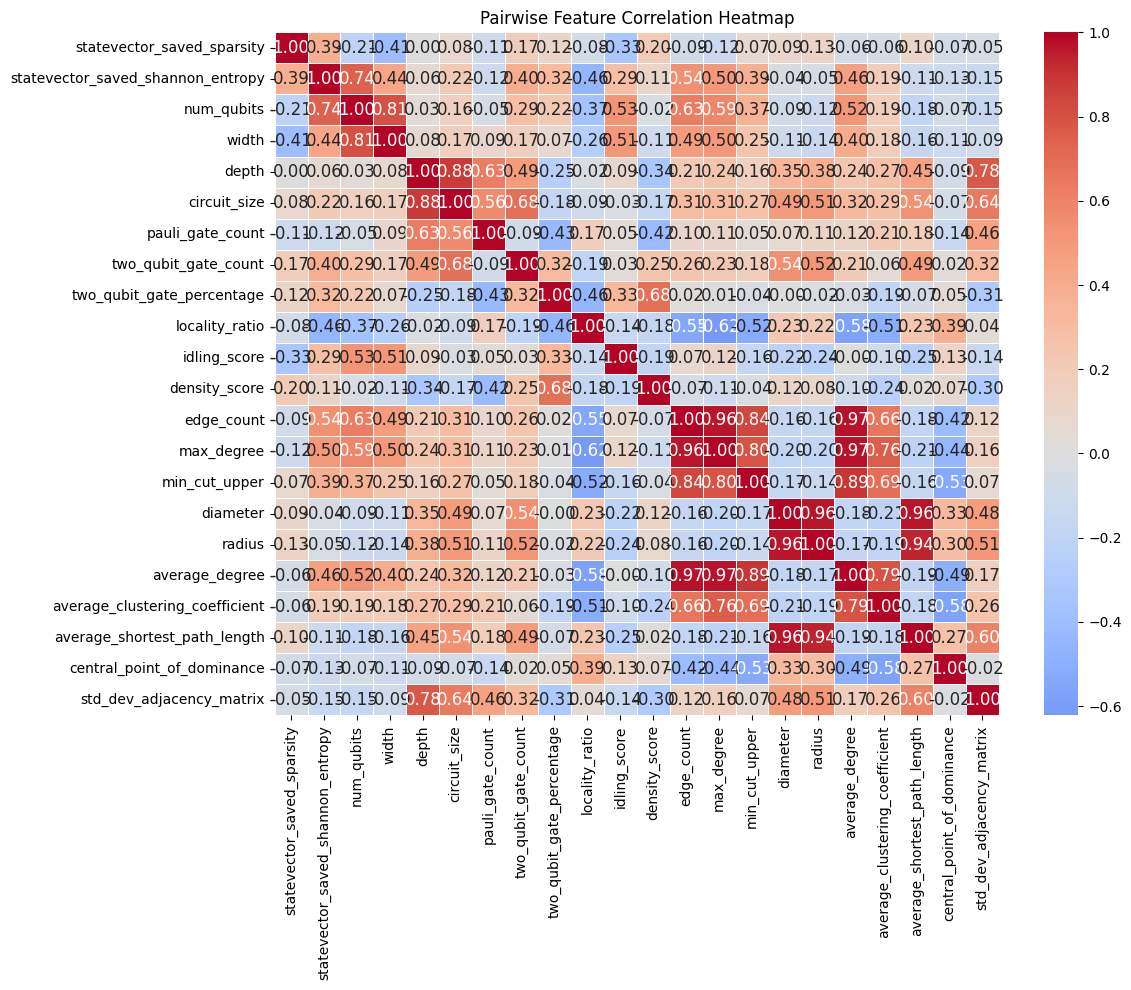

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns only
df_num = df.select_dtypes(include="number")

from utils import PlotCorrelationMatrix
# Plot correlation matrix
pcm = PlotCorrelationMatrix(df_num, FEATURES, (12, 10))


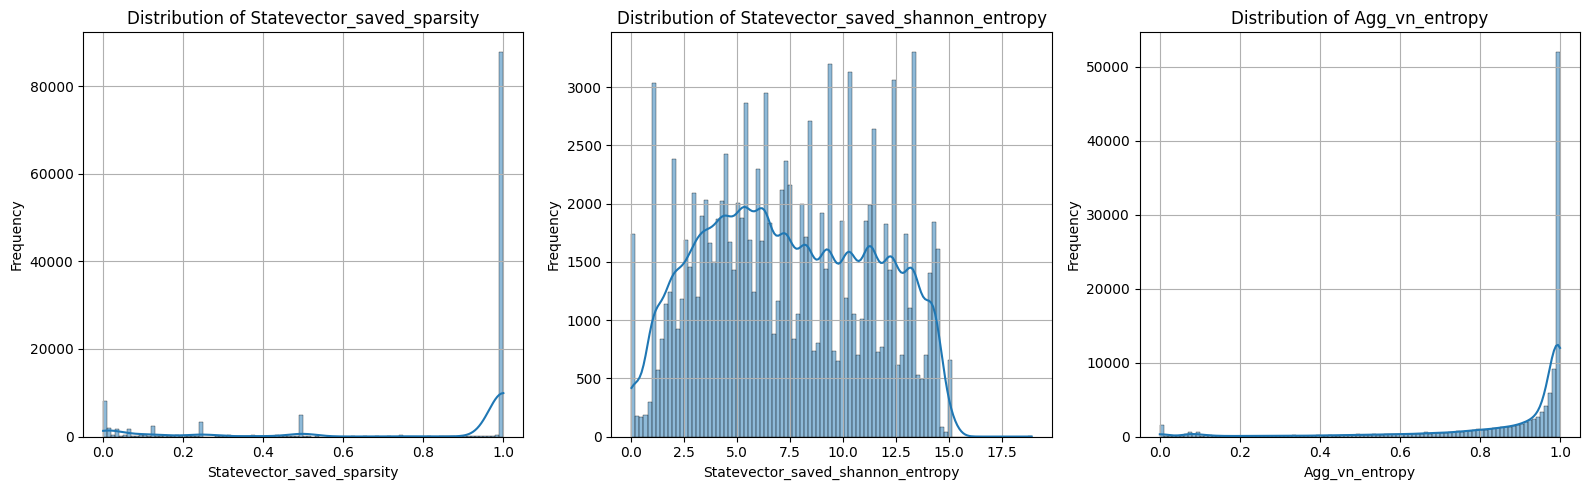

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let us aggregate the statevector_saved_von_neumann_entropy list into a mean value per row
df['agg_vn_entropy'] = df['statevector_saved_von_neumann_entropy'].apply(lambda x: np.mean(eval(x)) if pd.notna(x) else np.nan)

features = ["statevector_saved_sparsity", "statevector_saved_shannon_entropy", "agg_vn_entropy"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, features):
    sns.histplot(df[feature], bins=100, kde=True, ax=ax)
    ax.set_title(f"Distribution of {feature.capitalize()}")
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel("Frequency")
    ax.grid(True)

plt.tight_layout()
plt.show()


In [22]:
# Let us train a regression model to estimate sparsity and shannon_entropy.
from sklearn.model_selection import train_test_split

TARGET_SPARSITY = "statevector_saved_sparsity"
TARGET_SHANNON_ENTROPY = "statevector_saved_shannon_entropy"
TARGET_AGG_VN_ENTROPY = "agg_vn_entropy"
FEATURES_CLEAN = [
    f for f in FEATURES
    if f not in [TARGET_SHANNON_ENTROPY, TARGET_SPARSITY, TARGET_AGG_VN_ENTROPY, PRIMARY_KEY]
]
X = df[FEATURES_CLEAN]
y_sparsity = df[TARGET_SPARSITY]
y_shannon_entropy = df[TARGET_SHANNON_ENTROPY]
y_agg_vn_entropy = df[TARGET_AGG_VN_ENTROPY]

X_train, X_test, y_s_train, y_s_test, y_e_train, y_e_test, y_agg_vn_train, y_agg_vn_test = train_test_split(
    X, y_sparsity, y_shannon_entropy, y_agg_vn_entropy,
    test_size=0.2,
    random_state=42
)
print(len(X), len(X_train), len(X_test))
print(X_train.columns.tolist())

119693 95754 23939
['num_qubits', 'width', 'depth', 'circuit_size', 'pauli_gate_count', 'two_qubit_gate_count', 'two_qubit_gate_percentage', 'locality_ratio', 'idling_score', 'density_score', 'edge_count', 'max_degree', 'min_cut_upper', 'diameter', 'radius', 'average_degree', 'average_clustering_coefficient', 'average_shortest_path_length', 'central_point_of_dominance', 'std_dev_adjacency_matrix']


In [23]:
from sklearn.ensemble import RandomForestRegressor

sparsity_model = RandomForestRegressor(
    n_estimators=100,      # ↓ from 300
    max_depth=15,          # LIMIT depth
    min_samples_leaf=5,    # prevent overfitting
    random_state=42,
    n_jobs=-1
)

shannon_entropy_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

agg_vn_entropy_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

sparsity_model.fit(X_train, y_s_train)
shannon_entropy_model.fit(X_train, y_e_train)
agg_vn_entropy_model.fit(X_train, y_agg_vn_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [25]:
from sklearn.linear_model import LinearRegression

# Linear regression models
sparsity_lr = LinearRegression(n_jobs=-1)
shannon_entropy_lr = LinearRegression(n_jobs=-1)
agg_vn_entropy_lr = LinearRegression(n_jobs=-1)

# Fit models
sparsity_lr.fit(X_train, y_s_train)
shannon_entropy_lr.fit(X_train, y_e_train)
agg_vn_entropy_lr.fit(X_train, y_agg_vn_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"{name}")
    print(f"  R²   : {r2_score(y_test, y_pred):.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print()

evaluate(sparsity_model, X_test, y_s_test, "Sparsity Model")
evaluate(shannon_entropy_model, X_test, y_e_test, "Shannon Entropy Model")
evaluate(agg_vn_entropy_model, X_test, y_agg_vn_test, "Aggregated Von Neumann Entropy Model")

evaluate(sparsity_lr, X_test, y_s_test, "Sparsity Model (Linear Regression)")
evaluate(shannon_entropy_lr, X_test, y_e_test, "Shannon Entropy Model (Linear Regression)")
evaluate(agg_vn_entropy_lr, X_test, y_agg_vn_test, "Aggregated Von Neumann Entropy Model (Linear Regression)")

Sparsity Model
  R²   : 0.7619
  RMSE : 0.1806

Shannon Entropy Model
  R²   : 0.8922
  RMSE : 1.2999

Aggregated Von Neumann Entropy Model
  R²   : 0.6343
  RMSE : 0.1325

Sparsity Model (Linear Regression)
  R²   : 0.3648
  RMSE : 0.2950

Shannon Entropy Model (Linear Regression)
  R²   : 0.7030
  RMSE : 2.1578

Aggregated Von Neumann Entropy Model (Linear Regression)
  R²   : 0.2501
  RMSE : 0.1898



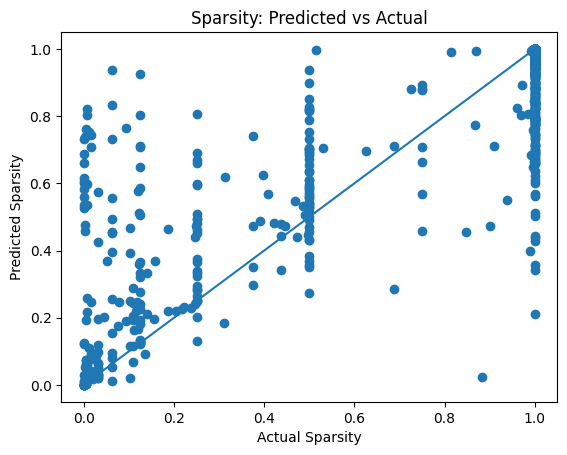

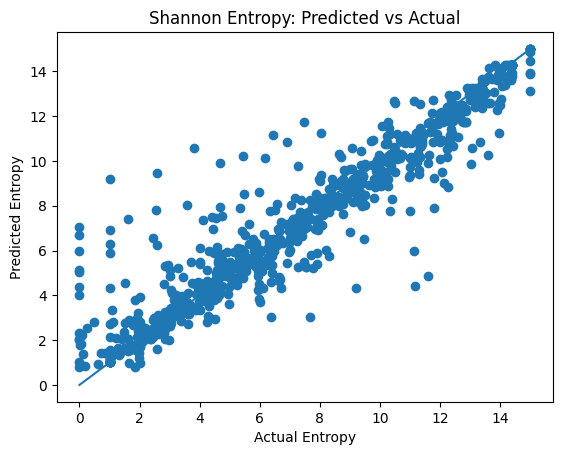

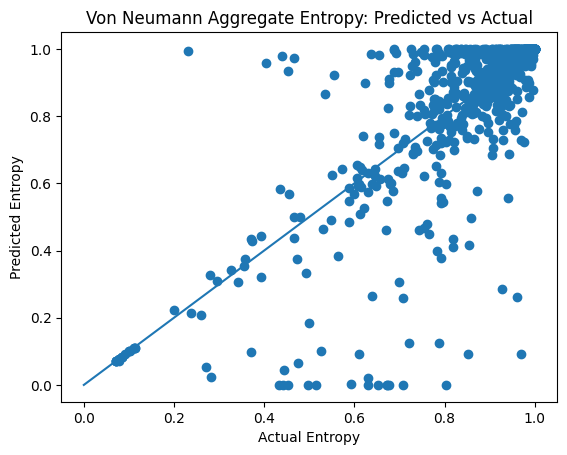

In [27]:
plotn = 1000
new_X = X_test.iloc[:plotn]

sparsity_pred = sparsity_model.predict(new_X)
shannon_entropy_pred = shannon_entropy_model.predict(new_X)
actual_agg_vn_entropy_pred = agg_vn_entropy_model.predict(new_X)

actual_sparsity = y_s_test.iloc[:plotn]
shannon_actual_entropy = y_e_test.iloc[:plotn]
agg_vn_actual_entropy = y_agg_vn_test.iloc[:plotn]

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(actual_sparsity, sparsity_pred)
plt.plot(
    [actual_sparsity.min(), actual_sparsity.max()],
    [actual_sparsity.min(), actual_sparsity.max()]
)
plt.xlabel("Actual Sparsity")
plt.ylabel("Predicted Sparsity")
plt.title("Sparsity: Predicted vs Actual")
plt.show()

plt.figure()
plt.scatter(shannon_actual_entropy, shannon_entropy_pred)
plt.plot(
    [shannon_actual_entropy.min(), shannon_actual_entropy.max()],
    [shannon_actual_entropy.min(), shannon_actual_entropy.max()]
)
plt.xlabel("Actual Entropy")
plt.ylabel("Predicted Entropy")
plt.title("Shannon Entropy: Predicted vs Actual")
plt.show()

plt.figure()
plt.scatter(actual_agg_vn_entropy_pred, agg_vn_actual_entropy)
plt.plot(
    [agg_vn_actual_entropy.min(), agg_vn_actual_entropy.max()],
    [agg_vn_actual_entropy.min(), agg_vn_actual_entropy.max()]
)
plt.xlabel("Actual Entropy")
plt.ylabel("Predicted Entropy")
plt.title("Von Neumann Aggregate Entropy: Predicted vs Actual")
plt.show()


# Sparsity Bin Classifier

In [10]:
bins = [
    0.0,
    0.1,
    0.2,
    0.4,  
    0.6,  
    1.01  
]

# bins = [0.0, 0.5, 0.6, 1.01]

labels = [str(bins[i])+ "-" + str(bins[i+1]) for i in range(len(bins)-1)]

df["sparsity_bin"] = pd.cut(
    df["statevector_saved_sparsity"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


In [11]:
from sklearn.model_selection import train_test_split

X = df[FEATURES_CLEAN]
y = df["sparsity_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [12]:
from sklearn.ensemble import RandomForestClassifier

modelSparsityClassifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=200,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

modelSparsityClassifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",200
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
from sklearn.metrics import classification_report

y_pred = modelSparsityClassifier.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)

              precision    recall  f1-score   support

     0.0-0.1      0.657     0.761     0.705      3664
     0.1-0.2      0.257     0.555     0.352      1001
     0.2-0.4      0.331     0.367     0.348      1258
     0.4-0.6      0.244     0.610     0.348      1530
    0.6-1.01      0.974     0.793     0.874     22471

    accuracy                          0.754     29924
   macro avg      0.493     0.617     0.525     29924
weighted avg      0.847     0.754     0.787     29924



In [14]:
bin_counts = df["sparsity_bin"].value_counts().sort_index()
total = bin_counts.sum()

print("Sparsity bin counts:")
for label, count in bin_counts.items():
    pct = 100 * count / total
    print(f"{label:10s}: {count:8d}  ({pct:6.2f}%)")


Sparsity bin counts:
0.0-0.1   :    14657  ( 12.25%)
0.1-0.2   :     4002  (  3.34%)
0.2-0.4   :     5033  (  4.20%)
0.4-0.6   :     6118  (  5.11%)
0.6-1.01  :    89883  ( 75.09%)


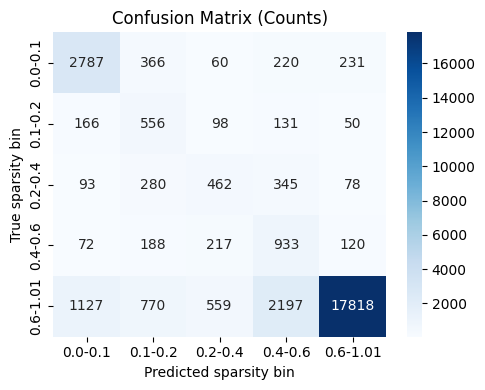

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = modelSparsityClassifier.classes_

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sparsity bin")
plt.ylabel("True sparsity bin")
plt.title("Confusion Matrix (Counts)")
plt.tight_layout()
plt.show()

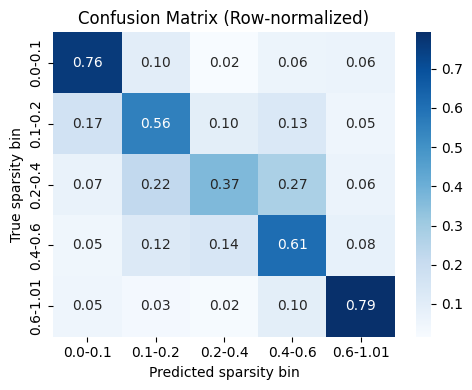

In [16]:
cm_norm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true"
)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sparsity bin")
plt.ylabel("True sparsity bin")
plt.title("Confusion Matrix (Row-normalized)")
plt.tight_layout()
plt.show()


In [17]:
importance = pd.Series(
    modelSparsityClassifier.feature_importances_,
    index=FEATURES_CLEAN
).sort_values(ascending=False)

importance.head(20)

pauli_gate_count                  0.133648
idling_score                      0.104112
density_score                     0.088075
std_dev_adjacency_matrix          0.087579
average_clustering_coefficient    0.062265
average_shortest_path_length      0.055375
two_qubit_gate_percentage         0.051073
num_qubits                        0.047336
two_qubit_gate_count              0.043425
average_degree                    0.040534
width                             0.037112
min_cut_upper                     0.036287
radius                            0.034482
central_point_of_dominance        0.032628
circuit_size                      0.032277
depth                             0.028661
locality_ratio                    0.025595
diameter                          0.025305
edge_count                        0.019845
max_degree                        0.014386
dtype: float64